In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

CUDA available: True
GPU Name: Tesla T4


In [2]:
!pip install torch torchvision matplotlib pillow tqdm

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [4]:
os.makedirs("shapes_dataset", exist_ok=True)
print("Dataset folder created successfully!")

Dataset folder created successfully!


In [5]:
def generate_shape(shape, size=64):
    img = Image.new("RGB", (size, size), "white")
    draw = ImageDraw.Draw(img)

    if shape == "square":
        draw.rectangle([16, 16, 48, 48], fill="blue")

    elif shape == "circle":
        draw.ellipse([16, 16, 48, 48], fill="red")

    elif shape == "triangle":
        draw.polygon([(32, 16), (16, 48), (48, 48)], fill="green")

    return img

In [6]:
shapes = ["square", "circle", "triangle"]
num_images_per_shape = 100

for label, shape in enumerate(shapes):
    shape_folder = f"shapes_dataset/{shape}"
    os.makedirs(shape_folder, exist_ok=True)

    for i in range(num_images_per_shape):
        img = generate_shape(shape)
        img.save(f"{shape_folder}/{shape}_{i}.png")

print("Dataset created successfully!")

Dataset created successfully!


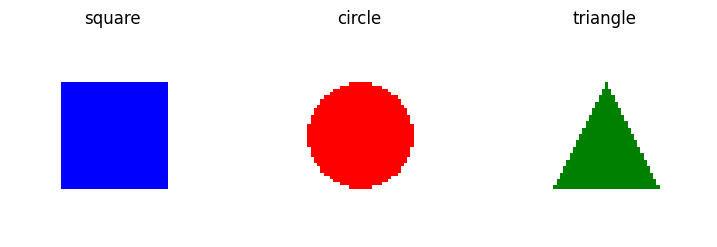

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

for i, shape in enumerate(shapes):
    img = Image.open(f"shapes_dataset/{shape}/{shape}_0.png")
    axes[i].imshow(img)
    axes[i].set_title(shape)
    axes[i].axis("off")

plt.show()

In [8]:
from torchvision import transforms
from torch.utils.data import Dataset
from PIL import Image
import os

class ShapesDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.shapes = ["square", "circle", "triangle"]
        self.image_paths = []
        self.labels = []

        for label, shape in enumerate(self.shapes):
            folder = os.path.join(root_dir, shape)
            for file in os.listdir(folder):
                if file.endswith(".png"):
                    self.image_paths.append(os.path.join(folder, file))
                    self.labels.append(label)

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        image = self.transform(image)
        label = self.labels[idx]
        return image, label

In [9]:
from torch.utils.data import DataLoader

dataset = ShapesDataset("shapes_dataset")
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print("Total images:", len(dataset))

Total images: 300


In [10]:
images, labels = next(iter(dataloader))

print("Image batch shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 64, 64])
Labels shape: torch.Size([32])
Labels: tensor([0, 0, 1, 0, 0, 2, 2, 2, 2, 2])


In [11]:
class Generator(nn.Module):
    def __init__(self, noise_dim=100, num_classes=3):
        super(Generator, self).__init__()

        self.label_emb = nn.Embedding(num_classes, num_classes)

        self.model = nn.Sequential(
            nn.Linear(noise_dim + num_classes, 256),
            nn.ReLU(True),

            nn.Linear(256, 512),
            nn.ReLU(True),

            nn.Linear(512, 1024),
            nn.ReLU(True),

            nn.Linear(1024, 3 * 64 * 64),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_input = self.label_emb(labels)
        x = torch.cat((noise, label_input), dim=1)
        img = self.model(x)
        img = img.view(-1, 3, 64, 64)
        return img

In [12]:
class Discriminator(nn.Module):
    def __init__(self, num_classes=3):
        super(Discriminator, self).__init__()

        self.label_emb = nn.Embedding(num_classes, num_classes)

        self.model = nn.Sequential(
            nn.Linear(3 * 64 * 64 + num_classes, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        img_flat = img.view(img.size(0), -1)
        label_input = self.label_emb(labels)
        x = torch.cat((img_flat, label_input), dim=1)
        validity = self.model(x)
        return validity

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"

generator = Generator().to(device)
discriminator = Discriminator().to(device)

print("Generator and Discriminator created successfully!")

Generator and Discriminator created successfully!


In [14]:
criterion = nn.BCELoss()

optimizer_G = optim.Adam(generator.parameters(), lr=0.0002)
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002)

print("Loss function and optimizers initialized!")

Loss function and optimizers initialized!


In [15]:
noise_dim = 100
num_epochs = 50

In [16]:
for epoch in range(num_epochs):
    for real_imgs, labels in dataloader:

        batch_size = real_imgs.size(0)

        real_imgs = real_imgs.to(device)
        labels = labels.to(device)

        valid = torch.ones(batch_size, 1).to(device)
        fake = torch.zeros(batch_size, 1).to(device)

        # ---------------------
        # Train Generator
        # ---------------------
        optimizer_G.zero_grad()

        z = torch.randn(batch_size, noise_dim).to(device)
        gen_labels = labels

        generated_imgs = generator(z, gen_labels)
        g_loss = criterion(discriminator(generated_imgs, gen_labels), valid)

        g_loss.backward()
        optimizer_G.step()

        # ---------------------
        # Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()

        real_loss = criterion(discriminator(real_imgs, labels), valid)
        fake_loss = criterion(
            discriminator(generated_imgs.detach(), gen_labels), fake
        )

        d_loss = (real_loss + fake_loss) / 2

        d_loss.backward()
        optimizer_D.step()

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"D Loss: {d_loss.item():.4f}, "
        f"G Loss: {g_loss.item():.4f}"
    )

Epoch [1/50] D Loss: 0.4628, G Loss: 0.5055
Epoch [2/50] D Loss: 0.7416, G Loss: 0.4261
Epoch [3/50] D Loss: 0.1244, G Loss: 2.3533
Epoch [4/50] D Loss: 0.0404, G Loss: 2.6551
Epoch [5/50] D Loss: 0.1247, G Loss: 1.6589
Epoch [6/50] D Loss: 0.0817, G Loss: 1.9468
Epoch [7/50] D Loss: 0.1300, G Loss: 1.4959
Epoch [8/50] D Loss: 0.1594, G Loss: 1.3331
Epoch [9/50] D Loss: 0.0138, G Loss: 3.6260
Epoch [10/50] D Loss: 0.0042, G Loss: 4.9515
Epoch [11/50] D Loss: 0.0127, G Loss: 3.8217
Epoch [12/50] D Loss: 0.0110, G Loss: 3.9236
Epoch [13/50] D Loss: 0.0062, G Loss: 4.4809
Epoch [14/50] D Loss: 0.4319, G Loss: 7.6881
Epoch [15/50] D Loss: 0.3413, G Loss: 13.3298
Epoch [16/50] D Loss: 0.2051, G Loss: 1.1839
Epoch [17/50] D Loss: 0.6844, G Loss: 0.2957
Epoch [18/50] D Loss: 0.8918, G Loss: 0.1863
Epoch [19/50] D Loss: 0.4973, G Loss: 0.5139
Epoch [20/50] D Loss: 0.4085, G Loss: 0.6354
Epoch [21/50] D Loss: 0.2839, G Loss: 0.9054
Epoch [22/50] D Loss: 0.0939, G Loss: 1.8557
Epoch [23/50] D Lo

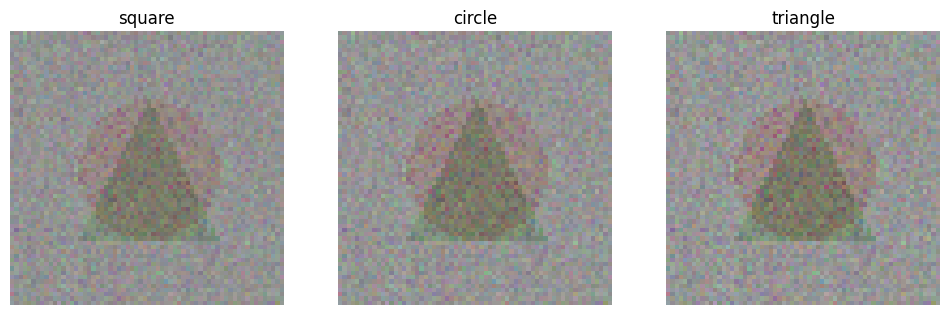

In [18]:
import matplotlib.pyplot as plt

generator.eval()

shape_names = ["square", "circle", "triangle"]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for label in range(3):
    z = torch.randn(1, 100).to(device)
    lbl = torch.tensor([label]).to(device)

    with torch.no_grad():
        generated_img = generator(z, lbl)

    # Convert image to display format
    img = generated_img.squeeze().permute(1, 2, 0).cpu().numpy()
    img = (img + 1) / 2   # [-1,1] → [0,1]
    img = img.clip(0, 1)

    axes[label].imshow(img)
    axes[label].set_title(shape_names[label])
    axes[label].axis("off")

plt.show()